### Libraries

In [ ]:
import pandas as pd
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

In [2]:
from datasets import Dataset
from transformers import BertTokenizer, TrainingArguments, Trainer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [74]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, accuracy_score

### Setup

In [3]:
df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/preparation/modeldata.csv")

In [4]:
print(df.columns)
print(df.shape)

Index(['verse_id', 'song_id', 'ori_track_name', 'clean_track_name',
       'all_artists', 'primary_artist', 'artist_genres', 'main_genre',
       'explicit', 'section', 'verse', 'language', 'language.1', 'confidence',
       'confidence.1', 'label'],
      dtype='str')
(22878, 16)


In [5]:
# Class balance check
print(df['label'].value_counts())

label
0    11439
1    11439
Name: count, dtype: int64


In [6]:
# Select only the columns we need
df = df[['verse', 'label']]

In [7]:
# Convert to Hugging Face format
dataset = Dataset.from_pandas(df)

In [8]:
# Fixes the [WinError 3] by explicitly setting a local cache directory
cache_dir = "C:/Users/User/Documents/devanasokan_fyp/huggingface_cache"
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

In [9]:
# Tell Hugging Face to use this directory
os.environ['HF_HOME'] = cache_dir

# This turns off the annoying symlink warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

### Tokenization

In [10]:
# Initiate with the cache path
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', cache_dir=cache_dir)

In [11]:
def preprocess_function(examples):
    # This creates the 'input_ids' and 'attention_mask' BERT needs
    return tokenizer(examples["verse"], truncation=True, padding="max_length", max_length=512)

tokenized_dataset = dataset.map(preprocess_function, batched=True)

Map: 100%|██████████| 22878/22878 [00:04<00:00, 4939.50 examples/s]


### Split Data (Train, Validation, Test)

In [65]:
# Ratio Used --> 70% training, 15% validation, 15% testing

# Set validation and test ratios (customizable)
desired_validation_ratio = 0.15
test_ratio = 0.15
training_ratio = 1 - desired_validation_ratio - test_ratio

# Calculate validation ratio based on the desired split
validation_ratio = desired_validation_ratio / (1 - test_ratio)  # This ensures the remaining data is split correctly

print(f"Test Ratio: {test_ratio}, Validation Ratio: {validation_ratio}")

Test Ratio: 0.15, Validation Ratio: 0.17647058823529413


In [61]:
# Split the dataset into training and testing sets
full_dataset = tokenized_dataset.train_test_split(test_size=test_ratio, seed=42)

# Split the training set into training and validation sets
train_valid_dataset = full_dataset['train'].train_test_split(test_size=validation_ratio, seed=42)

In [62]:
print("Training set size:", len(train_valid_dataset['train']))
print("Validation set size:", len(train_valid_dataset['test']))
print("Test set size:", len(full_dataset['test']))

Training set size: 16014
Validation set size: 3432
Test set size: 3432


In [34]:
print(train_valid_dataset) 
print(full_dataset["test"])

DatasetDict({
    train: Dataset({
        features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16014
    })
    test: Dataset({
        features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3432
    })
})
Dataset({
    features: ['verse', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3432
})


### Model Training

In [35]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_name = "distilbert-base-uncased" # Or any model from the Hugging Face Hub

# 1. Load the tokenizer (must match the model)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Load the model with a classification head
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2943.14it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
import evaluate
metric = evaluate.load("accuracy")

In [ ]:
# Metric computation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # argmax picks the highest probability (0 or 1)
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [38]:
# Set training arguments
training_args = TrainingArguments(
    output_dir="./results",          # Folder where checkpoints are saved
    eval_strategy="epoch",     # Run evaluation after every epoch
    save_strategy="epoch",           # Save model after every epoch
    learning_rate=2e-5,              # Standard BERT fine-tuning rate
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=16,   # Batch size for evaluation
    num_train_epochs=3,              # Total passes through the data
    weight_decay=0.01,               # Regularization to prevent overfitting
    load_best_model_at_end=True,     # Keeps the best version of the model
    fp16=torch.cuda.is_available()  # Use Mixed Precision if on GPU for 2x speed
)

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_valid_dataset["train"],
    eval_dataset=train_valid_dataset["test"],
    compute_metrics=compute_metrics,
)

print(trainer.compute_metrics)

<function compute_metrics at 0x000001942B0FC4A0>


In [40]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.332863,0.285749,0.875874
2,0.214258,0.303442,0.883159
3,0.145310,0.405142,0.886072


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.50s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3003, training_loss=0.24304626808141097, metrics={'train_runtime': 1371.2814, 'train_samples_per_second': 35.034, 'train_steps_per_second': 2.19, 'total_flos': 6363998766231552.0, 'train_loss': 0.24304626808141097, 'epoch': 3.0})

In [41]:
history = pd.DataFrame(trainer.state.log_history)
print(history)

       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.396329   8.862243   1.668332e-05  0.499500   500        NaN   
1  0.332863   4.106877   1.335331e-05  0.999001  1000        NaN   
2       NaN        NaN            NaN  1.000000  1001   0.285749   
3  0.236161   4.844387   1.002997e-05  1.498501  1500        NaN   
4  0.214258   9.843578   6.699967e-06  1.998002  2000        NaN   
5       NaN        NaN            NaN  2.000000  2002   0.303442   
6  0.134519  22.561541   3.369963e-06  2.497502  2500        NaN   
7  0.145310   0.237285   3.996004e-08  2.997003  3000        NaN   
8       NaN        NaN            NaN  3.000000  3003   0.405142   
9       NaN        NaN            NaN  3.000000  3003        NaN   

   eval_accuracy  eval_runtime  eval_samples_per_second  \
0            NaN           NaN                      NaN   
1            NaN           NaN                      NaN   
2       0.875874       27.2264                  126.054   
3            Na

### Model Evaluation

In [ ]:
# Evaluate the model on the test set
predictions = trainer.predict(full_dataset["test"])

OSError: Cannot save file into a non-existent directory: 'C:\Users\User\Documents\devanasokan_fyp\evaluation'

In [43]:
# Save the predictions to a CSV file
predictions_df = pd.DataFrame({
    'verse': full_dataset["test"]["verse"],
    'true_label': predictions.label_ids,
    'predicted_label': np.argmax(predictions.predictions, axis=-1)
})
predictions_df.to_csv("C:/Users/User/Documents/devanasokan_fyp/evaluation/distilbert_predictions.csv", index=False)

In [87]:
# --something
logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits to predicted classes
y_pred = np.argmax(predictions.predictions, axis=-1)

AttributeError: 'DataFrame' object has no attribute 'predictions'

In [79]:
# Calculate probabilities using softmax
probabilities = softmax(logits, axis=1)

# Get the probabilities for the positive class (label 1)
y_scores = probabilities[:, 1]

#### Classification Report

In [85]:
report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_true, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"DISTILBERT CLASSIFICATION REPORT:")
print(f"Train Ratio: {training_ratio:.2f}, Validation Ratio: {desired_validation_ratio:.2f}, Test Ratio: {test_ratio:.2f}\n")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

DISTILBERT CLASSIFICATION REPORT:
Train Ratio: 0.70, Validation Ratio: 0.15, Test Ratio: 0.15

Accuracy: 0.8653846153846154
Precision: 0.8914919852034525
Recall: 0.8348729792147807
F1-score: 0.8622540250447227


#### ROC-AUC Curve

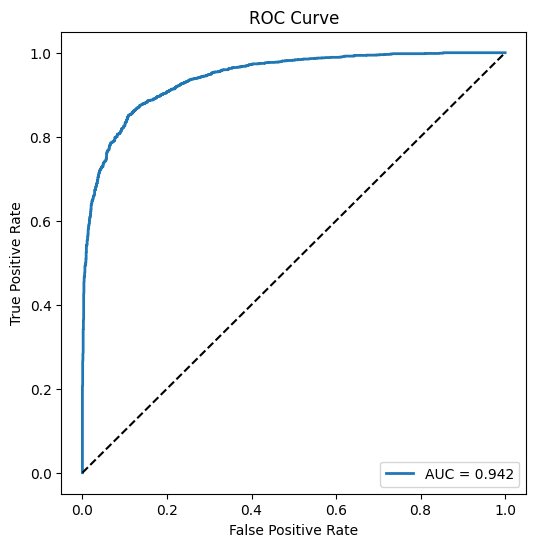

In [81]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9478908247124915


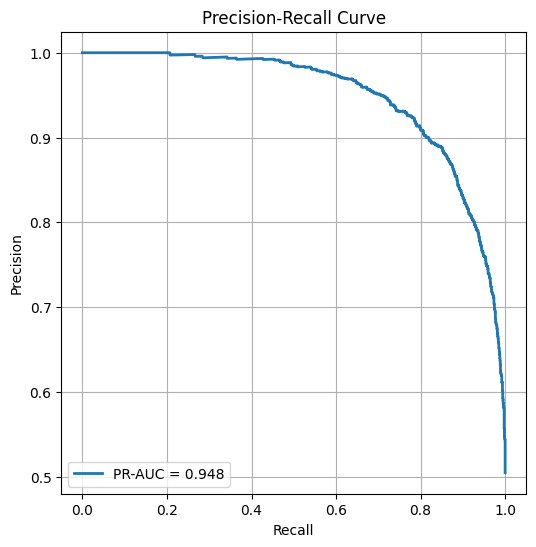

In [82]:
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

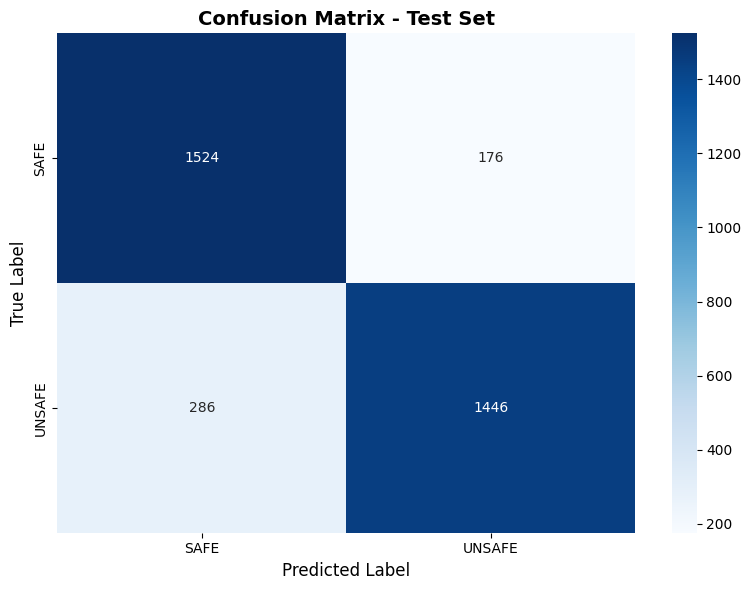

In [78]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

#### Save Model and Test

In [56]:
# Save the version currently in the trainer's brain
trainer.save_model("./my_final_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


In [57]:
# TEST MODEL

from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

# Load the model and tokenizer from your local folder
path = "./my_final_model"
model = AutoModelForSequenceClassification.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased") # Ensure you saved the tokenizer there too!

# Create a 'pipeline' (the easiest way to use the model)
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7643.24it/s]


In [58]:
# Test it on a new sentence
result = classifier("kiss it from my lips")
print(result)

[{'label': 'LABEL_0', 'score': 0.586175799369812}]


In [59]:
import accelerate
print(accelerate.__version__)

1.13.0


In [60]:
import accelerate
import transformers
print(f"Accelerate version: {accelerate.__version__}")
print(f"Transformers version: {transformers.__version__}")

Accelerate version: 1.13.0
Transformers version: 5.3.0


In [61]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
